# Начало и предобработка данных

In [1]:
# .\.venv\Scripts\Activate.ps1

In [2]:
import pandas as pd 
import numpy as np

In [3]:
dataset_3 = pd.read_csv("house_kg_sell_flats_1783230474.csv")

In [4]:
len(dataset_3)

11998

In [5]:
dataset_3.head(3)

,main,address,added,upped,view_count,hearts,lat,lon,Тип предложения,Серия,...,Возможность обмена,Разное,Пол,Возможность ипотеки,Площадь участка,Канализация,Питьевая вода,Электричество,usd_price,Описание от продавца
0,"2-комн. кв., 43 м2","Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",Добавлено 11 часов назад,Поднято 11 часов назад,135.0,NaN,42.8833,74.6374,от собственника,104 серия,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна..."
1,"2-комн. кв., 57 м2","Бишкек, Горького - Алма-Атинская, Горького",Добавлено 2 месяца назад,Поднято 8 часов назад,18288.0,43.0,42.8568,74.6308,от собственника,элитка,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...
2,"2-комн. кв., 75.78 м2","Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",Добавлено 3 месяца назад,Поднято 40 минут назад,5765.0,16.0,42.8166,74.6113,от собственника,элитка,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...


In [6]:
dataset_3 = dataset_3[dataset_3["usd_price"] > 0]

In [7]:
# Удалит строку, если пусто либо в "Дом", либо в "Серия"
dataset_3 = dataset_3.dropna(subset=['Дом', 'Серия'])

In [8]:
dataset_3["Дом"].isna().sum()

np.int64(0)

In [9]:
dataset_3.columns

Index(['main', 'address', 'added', 'upped', 'view_count', 'hearts', 'lat',
       'lon', 'Тип предложения', 'Серия', 'Дом', 'Этаж', 'Площадь',
       'Отопление', 'Состояние', 'Газ', 'Санузел', 'Балкон', 'Входная дверь',
       'Парковка', 'Высота потолков', 'Безопасность',
       'Правоустанавливающие документы', 'Телефон', 'Интернет', 'Мебель',
       'Возможность рассрочки', 'Возможность обмена', 'Разное', 'Пол',
       'Возможность ипотеки', 'Площадь участка', 'Канализация',
       'Питьевая вода', 'Электричество', 'usd_price', 'Описание от продавца'],
      dtype='str')

In [10]:
# если пропущкнных значений больше 7-8 к
columns_to_drop = [
    "added",
    "upped",
    "view_count",
    "hearts",
    "Санузел",
    "Балкон",
    "Безопасность",
    "Входная дверь",
    "Парковка",
    "Телефон",
    "Интернет",
    "Мебель",
    "Возможность рассрочки",
    "Возможность обмена",
    "Разное",
    "Пол",
    "Возможность ипотеки",
    "Площадь участка",
    "Канализация",
    "Питьевая вода",
    "Электричество",
    "Газ",
    
]

# Удаляем колонки (errors='ignore' предотвратит ошибку, если какой-то колонки нет в датасете)
dataset_3 = dataset_3.drop(columns=columns_to_drop, errors='ignore')


In [11]:
dataset_3.columns

Index(['main', 'address', 'lat', 'lon', 'Тип предложения', 'Серия', 'Дом',
       'Этаж', 'Площадь', 'Отопление', 'Состояние', 'Высота потолков',
       'Правоустанавливающие документы', 'usd_price', 'Описание от продавца'],
      dtype='str')

In [12]:
dataset_3 = dataset_3[~dataset_3['main'].str.contains('свободная планировка кв., 1 м2', case=False, na=False)]

In [13]:
dataset_3['main'].head(3)

0       2-комн. кв., 43 м2
1       2-комн. кв., 57 м2
2    2-комн. кв., 75.78 м2
Name: main, dtype: str

In [14]:
# надо добавить новые колонки rooms и square. надо данные из колонки main преобразовать. в начале идет комнаты после запятой площадь. также есть свободная планировка

In [15]:
dataset_3[dataset_3['main'].str.contains('свободная планировка кв., 1 м2', case=False, na=False)]

,main,address,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца


In [16]:
# Фильтруем строки по вхождению текста "свободная планировка" в колонку "main"
dataset_3[dataset_3['main'].str.contains('свободная планировка', case=False, na=False)]['main'].value_counts().sum()


np.int64(31)

In [17]:
# Высота потолков 5515 null
# Правоустанавливающие документы 5698 null
# Описание от продавца 601 null хз что делать

In [18]:
dataset_3['Дом'].unique()

<StringArray>
[          'кирпичный', 'монолитный, 2024 г.', 'монолитный, 2026 г.',
 'монолитный, 2022 г.', 'монолитный, 2016 г.',  'кирпичный, 2026 г.',
          'монолитный',  'кирпичный, 2025 г.', 'монолитный, 2015 г.',
 'монолитный, 2023 г.',
 ...
  'кирпичный, 1966 г.',  'панельный, 2018 г.',  'кирпичный, 2030 г.',
  'панельный, 1973 г.', 'монолитный, 2012 г.', 'монолитный, 1987 г.',
 'монолитный, 1981 г.', 'монолитный, 1988 г.',  'кирпичный, 1950 г.',
  'панельный, 2011 г.']
Length: 175, dtype: str

In [19]:
# Создаем независимые копии датасета
data_boost = dataset_3.copy()
data_reg = dataset_3.copy()

# --- Шаг 0. Базовое извлечение данных ---
# Извлекаем комнаты (пока с NaN для свободной планировки)
extracted_rooms = dataset_3['main'].str.extract(r'(\d+)-комн\.')
rooms_series = pd.to_numeric(extracted_rooms[0], errors='coerce')

# Извлекаем площадь (число с плавающей точкой)
extracted_square = dataset_3['main'].str.extract(r',\s*(\d+\.?\d*)\s*м2')
square_series = pd.to_numeric(extracted_square[0], errors='coerce')

# Флаг свободной планировки (1 - да, 0 - нет)
is_free_layout_series = dataset_3['main'].str.contains('свободная планировка', case=False, na=False).astype(int)


# --- 1. Подготовка data_boost (для градиентного бустинга) ---
data_boost['rooms'] = rooms_series  # Оставляем NaN для свободной планировки
data_boost['square'] = square_series
data_boost['is_free_layout'] = is_free_layout_series


# --- 2. Подготовка data_reg (для линейных моделей) ---
data_reg['square'] = square_series

# Рассчитываем комнаты: делим площадь на 30 и округляем до целого
calculated_rooms = (square_series / 30).round()

# Если при делении получилось меньше 1 (или NaN из-за отсутствия площади), пишем 1
calculated_rooms = calculated_rooms.fillna(1).clip(lower=1).astype(int)

# Заполняем пропуски в rooms вычисленными значениями
data_reg['rooms'] = rooms_series.fillna(calculated_rooms).astype(int)


In [20]:
data_boost = data_boost.drop(columns = 'main')

In [21]:
data_boost.head(3)

,address,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,rooms,square,is_free_layout
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,от собственника,104 серия,кирпичный,4 этаж из 5,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",2.0,43.00,0
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,от собственника,элитка,"монолитный, 2024 г.",4 этаж из 12,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,2.0,57.00,0
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,от собственника,элитка,"монолитный, 2026 г.",13 этаж из 15,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,2.0,75.78,0


In [22]:
data_reg = data_reg.drop(columns = 'main')
data_reg.head(3)

,address,lat,lon,Тип предложения,Серия,Дом,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,square,rooms
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,от собственника,104 серия,кирпичный,4 этаж из 5,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",43.00,2
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,от собственника,элитка,"монолитный, 2024 г.",4 этаж из 12,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,57.00,2
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,от собственника,элитка,"монолитный, 2026 г.",13 этаж из 15,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,75.78,2


In [23]:
import re

# 1. Извлекаем тип дома (всё, что идет до первой запятой)
data_reg['house_type'] = data_reg['Дом'].apply(lambda x: str(x).split(',')[0].strip())

# 2. Извлекаем год постройки (ищем 4-значное число)
data_reg['build_year'] = data_reg['Дом'].apply(lambda x: re.search(r'(\d{4})', str(x)))
data_reg['build_year'] = data_reg['build_year'].apply(lambda x: int(x.group(1)) if x else None)

# 3. Рассчитываем медианный год постройки для каждого типа дома
# Для панельного будет 2016, кирпичного — 2023, монолитного — 2024
medians = data_reg.groupby('house_type')['build_year'].median()

# 4. Заполняем пропущенные годы постройки медианами соответствующих типов домов
data_reg['build_year'] = data_reg['build_year'].fillna(data_reg['house_type'].map(medians))
data_reg['build_year'] = data_reg['build_year'].astype(int)

# 5. Применяем One-Hot Encoding к колонке с типом дома
# dtype=int создаст колонки с 0 и 1 вместо True/False
data_reg = pd.get_dummies(data_reg, columns=['house_type', 'Тип предложения'], dtype=int)

# 6. Удаляем исходную строковую колонку "Дом", так как мы полностью извлекли из нее информацию
data_reg = data_reg.drop(columns=['Дом'])


In [24]:
data_reg.head(3)

,address,lat,lon,Серия,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,square,rooms,build_year,house_type_кирпичный,house_type_монолитный,house_type_панельный,Тип предложения_от агента,Тип предложения_от собственника
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,104 серия,4 этаж из 5,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",43.00,2,2023,1,0,0,0,1
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,элитка,4 этаж из 12,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,57.00,2,2024,0,1,0,0,1
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,элитка,13 этаж из 15,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,75.78,2,2026,0,1,0,0,1


In [25]:
# 1. Извлекаем тип дома в отдельную категориальную (строковую) колонку
data_boost['house_type'] = data_boost['Дом'].apply(lambda x: str(x).split(',')[0].strip())
data_boost['house_type'] = data_boost['house_type'].astype('category') # Приводим к типу category для удобства бустинга

# 2. Извлекаем год постройки (оставляем NaN на месте пропусков)
data_boost['build_year'] = data_boost['Дом'].apply(lambda x: re.search(r'(\d{4})', str(x)))
data_boost['build_year'] = data_boost['build_year'].apply(lambda x: int(x.group(1)) if x else None)

# 3. Удаляем исходную текстовую колонку "Дом"
data_boost = data_boost.drop(columns=['Дом'])

# 4. Применяем One-Hot Encoding к колонке "Тип предложения"
data_boost = pd.get_dummies(data_boost, columns=['Тип предложения'], dtype=int)


In [26]:
data_boost.head(3)

,address,lat,lon,Серия,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,rooms,square,is_free_layout,house_type,build_year,Тип предложения_от агента,Тип предложения_от собственника
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,104 серия,4 этаж из 5,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",2.0,43.00,0,кирпичный,NaN,0,1
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,элитка,4 этаж из 12,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,2.0,57.00,0,монолитный,2024.0,0,1
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,элитка,13 этаж из 15,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,2.0,75.78,0,монолитный,2026.0,0,1


In [27]:
# Объединяем улучшенные серии с обычными
dataset_3['Серия'] = dataset_3['Серия'].str.replace(' улучшенная', '', regex=False)

In [28]:
dataset_3['Серия'] = dataset_3['Серия'].replace(['102 серия', '107 серия'], 'ост. серии')

In [29]:
# Объединяем улучшенные серии с обычными
data_boost['Серия'] = data_boost['Серия'].str.replace(' улучшенная', '', regex=False)
data_reg['Серия'] = data_reg['Серия'].str.replace(' улучшенная', '', regex=False)


In [30]:
# 2. Объединяем 102 и 107 серию под названием "ост. серии"
data_boost['Серия'] = data_boost['Серия'].replace(['102 серия', '107 серия'], 'ост. серии')
data_reg['Серия'] = data_reg['Серия'].replace(['102 серия', '107 серия'], 'ост. серии')


In [31]:
# Применяем One-Hot Encoding к колонке "Серия" для линейной модели
data_reg = pd.get_dummies(data_reg, columns=['Серия'], dtype=int)

In [32]:
data_boost.head(3)

,address,lat,lon,Серия,Этаж,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,rooms,square,is_free_layout,house_type,build_year,Тип предложения_от агента,Тип предложения_от собственника
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,104 серия,4 этаж из 5,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",2.0,43.00,0,кирпичный,NaN,0,1
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,элитка,4 этаж из 12,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,2.0,57.00,0,монолитный,2024.0,0,1
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,элитка,13 этаж из 15,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,2.0,75.78,0,монолитный,2026.0,0,1


In [33]:
dataset_3 = dataset_3.dropna(subset=['Этаж'])

In [34]:
# 1. Функция для безопасного извлечения этажа и общего количества этажей
def parse_floor_data(val):
    if pd.isna(val):
        return None, None
    val = str(val).strip().lower()
    
    # Ищем стандартный шаблон "X этаж из Y"
    match = re.search(r'(\d+)\s*этаж\s*из\s*(\d+)', val)
    if match:
        return int(match.group(1)), int(match.group(2))
    
    # Ищем цоколь или подвал: "цоколь из Y этажей" / "подвал из Y этажей"
    # Цоколь и подвал приравниваем к 0-му этажу
    match_other = re.search(r'(цоколь|подвал)\s*из\s*(\d+)', val)
    if match_other:
        return 0, int(match_other.group(2))
        
    return None, None


# 2. Обрабатываем датасеты
for df in [data_boost, data_reg]:
    # Извлекаем числа
    parsed = df['Этаж'].apply(parse_floor_data)
    df['floor'] = [p[0] for p in parsed]
    df['total_floors'] = [p[1] for p in parsed]
    
    # Базовый расчет признаков
    df['floor_ratio'] = df['floor'] / df['total_floors']
    df['is_first_floor'] = (df['floor'] == 1).astype(int)
    # Флаг последнего этажа ставим только если общее кол-во этажей известно
    df['is_last_floor'] = ((df['floor'] == df['total_floors']) & df['total_floors'].notna()).astype(int)


# 3. Дополнительная обработка пропусков для data_reg (линейные модели)
# Так как линейная регрессия не обучится при наличии NaN, заполняем пропущенные значения медианами
floor_median = data_reg['floor'].median()
total_median = data_reg['total_floors'].median()

data_reg['floor'] = data_reg['floor'].fillna(floor_median)
data_reg['total_floors'] = data_reg['total_floors'].fillna(total_median)

# Пересчитываем признаки после заполнения пропусков в data_reg
data_reg['floor_ratio'] = data_reg['floor'] / data_reg['total_floors']
data_reg['is_first_floor'] = (data_reg['floor'] == 1).astype(int)
data_reg['is_last_floor'] = (data_reg['floor'] == data_reg['total_floors']).astype(int)


# 4. Удаляем исходную строковую колонку "Этаж", так как вся числовая информация из нее извлечена
data_boost = data_boost.drop(columns=['Этаж'])
data_reg = data_reg.drop(columns=['Этаж'])


In [35]:
data_boost = data_boost.drop(columns=['floor', 'total_floors'])
data_reg = data_reg.drop(columns=['floor', 'total_floors'])

In [36]:
data_reg.head(3)

,address,lat,lon,Площадь,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,...,Серия_индивид. планировка,Серия_малосемейка,Серия_ост. серии,Серия_пентхаус,Серия_сталинка,Серия_хрущевка,Серия_элитка,floor_ratio,is_first_floor,is_last_floor
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,43 м2,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",...,0,0,0,0,0,0,0,0.800000,0,0
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,57 м2,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,...,0,0,0,0,0,0,1,0.333333,0,0
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,75.78 м2,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,...,0,0,0,0,0,0,1,0.866667,0,0


In [37]:
data_boost['Площадь'] = data_boost['Площадь'].str.replace(' м2', '', regex=False)
data_reg['Площадь'] = data_reg['Площадь'].str.replace(' м2', '', regex=False)

In [38]:
# Удаляем дублирующую строковую колонку
data_boost = data_boost.drop(columns=['Площадь'])
data_reg = data_reg.drop(columns=['Площадь'])


In [39]:
dataset_3.info()

<class 'pandas.DataFrame'>
Index: 11992 entries, 0 to 11997
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   main                            11992 non-null  str    
 1   address                         11992 non-null  str    
 2   lat                             11992 non-null  float64
 3   lon                             11992 non-null  float64
 4   Тип предложения                 11992 non-null  str    
 5   Серия                           11992 non-null  str    
 6   Дом                             11992 non-null  str    
 7   Этаж                            11992 non-null  str    
 8   Площадь                         11992 non-null  str    
 9   Отопление                       9494 non-null   str    
 10  Состояние                       10570 non-null  str    
 11  Высота потолков                 6479 non-null   str    
 12  Правоустанавливающие документы  6294 non-null   

In [40]:
dataset_3['Отопление'].value_counts()

Отопление
центральное           4669
на газе               3729
автономное             654
электрическое          405
смешанное               20
без отопления           16
на твердом топливе       1
Name: count, dtype: int64

In [41]:
len(dataset_3[dataset_3['Отопление'].isna()])

2498

In [42]:
# 1. Функция группировки и заполнения пропусков
def preprocess_heating(val):
    if pd.isna(val):
        return 'не указано'
    val = str(val).strip().lower()
    
    # Объединяем редкие варианты в одну категорию "другое"
    if val in ['смешанное', 'без отопления', 'на твердом топливе']:
        return 'другое'
    return val


# 2. Применяем функцию к обоим датасетам
data_boost['Отопление'] = data_boost['Отопление'].apply(preprocess_heating)
data_reg['Отопление'] = data_reg['Отопление'].apply(preprocess_heating)


# 3. Подготовка колонок для обучения моделей

# Для data_reg: One-Hot Encoding
data_reg = pd.get_dummies(data_reg, columns=['Отопление'], dtype=int)

# Для data_boost: Приведение к категориальному типу
data_boost['Отопление'] = data_boost['Отопление'].astype('category')


In [43]:
data_boost.head(3)

,address,lat,lon,Серия,Отопление,Состояние,Высота потолков,Правоустанавливающие документы,usd_price,Описание от продавца,rooms,square,is_free_layout,house_type,build_year,Тип предложения_от агента,Тип предложения_от собственника,floor_ratio,is_first_floor,is_last_floor
0,"Бишкек, Чуй - Алматинка, Салиева 182/Алматинка",42.8833,74.6374,104 серия,центральное,хорошее,NaN,"договор купли-продажи, ...",78000.0,"Срочно ‼️ Продается светлая,теплая 2х комнатна...",2.0,43.00,0,кирпичный,NaN,0,1,0.800000,0,0
1,"Бишкек, Горького - Алма-Атинская, Горького",42.8568,74.6308,элитка,центральное,евроремонт,3 м.,NaN,97000.0,Срочно!!!\n\nНИЖЕ РЫНКА!!!\n\nПродаю полноценн...,2.0,57.00,0,монолитный,2024.0,0,1,0.333333,0,0
2,"Бишкек, Магистраль, ДУЙШЕЕВА/МОЛДОБАСАНОВА (НА...",42.8166,74.6113,элитка,на газе,под самоотделку (псо),NaN,"красная книга, ...",112000.0,Продаёт Собственник\nW/a +971523168274\n\nПрод...,2.0,75.78,0,монолитный,2026.0,0,1,0.866667,0,0


In [44]:
# 1. Заполняем пропуски в колонке "Состояние"
data_boost['Состояние'] = data_boost['Состояние'].fillna('не указано')
data_reg['Состояние'] = data_reg['Состояние'].fillna('не указано')

# 2. Для data_reg: Применяем One-Hot Encoding
data_reg = pd.get_dummies(data_reg, columns=['Состояние'], dtype=int)

# 3. Для data_boost: Приводим к категориальному типу
data_boost['Состояние'] = data_boost['Состояние'].astype('category')


In [45]:
# Удаляем колонку "Высота потолков" из обоих датасетов
data_boost = data_boost.drop(columns=['Высота потолков'])
data_reg = data_reg.drop(columns=['Высота потолков'])

In [46]:
data_reg = data_reg.drop(columns=['address', 'Описание от продавца'])

In [47]:
data_boost = data_boost.drop(columns=['Описание от продавца'])

In [48]:
# Извлекаем бинарные флаги для основных типов документов в обоих датасетах
for df in [data_boost, data_reg]:
    # Приводим к нижнему регистру и заполняем NaN пустой строкой для поиска
    docs_clean = df['Правоустанавливающие документы'].fillna('').str.lower()
    
    # Создаем флаги
    df['doc_ddu'] = docs_clean.str.contains('договор долевого участия', regex=False).astype(int)
    df['doc_tech_passport'] = docs_clean.str.contains('технический паспорт', regex=False).astype(int)
    df['doc_red_book'] = docs_clean.str.contains('красная книга', regex=False).astype(int)
    df['doc_sale_purchase'] = docs_clean.str.contains('договор купли-продажи', regex=False).astype(int)

# Теперь удаляем исходную текстовую колонку с документами
data_boost = data_boost.drop(columns=['Правоустанавливающие документы'])
data_reg = data_reg.drop(columns=['Правоустанавливающие документы'])


In [49]:
# 1. Извлекаем микрорайон/перекресток (вторая часть адреса)
district_series_boost = data_boost['address'].apply(
    lambda x: str(x).split(',')[1].strip() if len(str(x).split(',')) > 1 else 'не указано'
)

# 2. Заменяем "Алма-Атинская" и "Алма-атинская" на "Алматинка"
# Флаг (?i) делает поиск регистронезависимым
data_boost['district'] = district_series_boost.str.replace(r'(?i)алма-атинская', 'Алматинка', regex=True)


# 3. Дополнительно убираем саму колонку address
data_boost = data_boost.drop(columns=['address'])



In [82]:
data_reg.head(3)

,lat,lon,usd_price,square,rooms,build_year,house_type_кирпичный,house_type_монолитный,house_type_панельный,Тип предложения_от агента,...,Состояние_евроремонт,Состояние_не достроено,Состояние_не указано,Состояние_под самоотделку (псо),Состояние_среднее,Состояние_хорошее,doc_ddu,doc_tech_passport,doc_red_book,doc_sale_purchase
0,42.8833,74.6374,78000.0,43.00,2,2023,1,0,0,0,...,0,0,0,0,0,1,0,1,0,1
1,42.8568,74.6308,97000.0,57.00,2,2024,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
2,42.8166,74.6113,112000.0,75.78,2,2026,0,1,0,0,...,0,0,0,1,0,0,0,0,1,1


In [51]:
data_boost.head(3)

,lat,lon,Серия,Отопление,Состояние,usd_price,rooms,square,is_free_layout,house_type,...,Тип предложения_от агента,Тип предложения_от собственника,floor_ratio,is_first_floor,is_last_floor,doc_ddu,doc_tech_passport,doc_red_book,doc_sale_purchase,district
0,42.8833,74.6374,104 серия,центральное,хорошее,78000.0,2.0,43.00,0,кирпичный,...,0,1,0.800000,0,0,0,1,0,1,Чуй - Алматинка
1,42.8568,74.6308,элитка,центральное,евроремонт,97000.0,2.0,57.00,0,монолитный,...,0,1,0.333333,0,0,0,0,0,0,Горького - Алматинка
2,42.8166,74.6113,элитка,на газе,под самоотделку (псо),112000.0,2.0,75.78,0,монолитный,...,0,1,0.866667,0,0,0,0,1,1,Магистраль


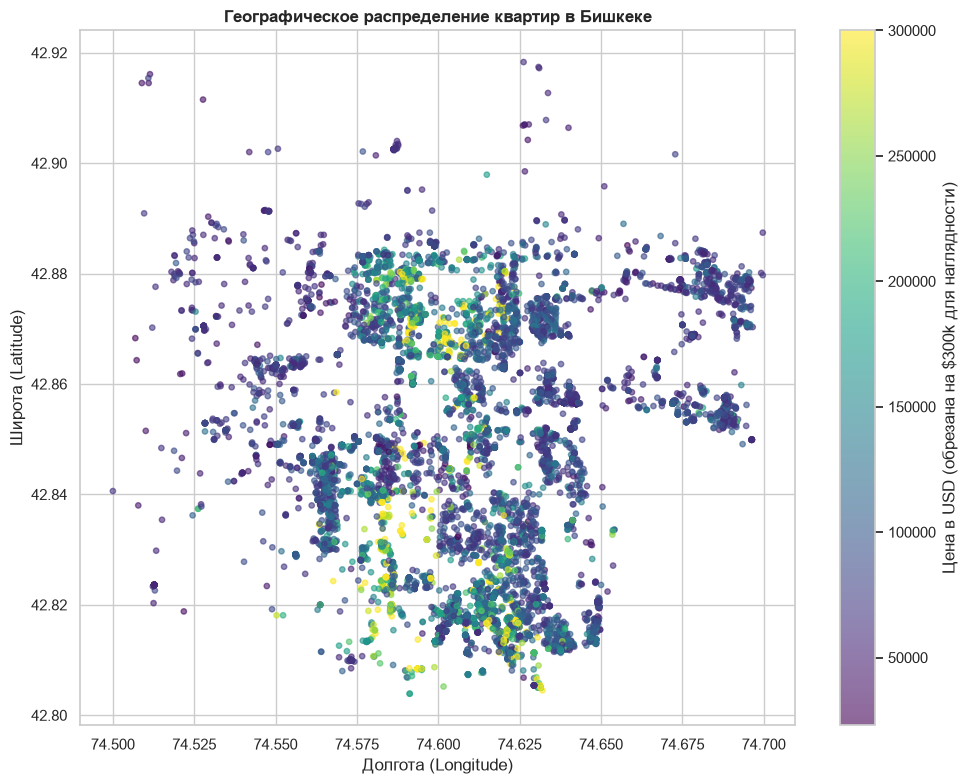

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настраиваем стиль графиков
sns.set_theme(style="whitegrid")

# --- 1. Подготовка данных ---
df_clean = dataset_3[
    (dataset_3['lat'].between(42.80, 42.92)) & 
    (dataset_3['lon'].between(74.50, 74.70))
].copy()

# --- ГРАФИК 1: Scatterplot координат ---
plt.figure(figsize=(10, 8))

# Клипаем цвет на $300k для контрастности
scatter = plt.scatter(
    x=df_clean['lon'], 
    y=df_clean['lat'], 
    c=np.minimum(df_clean['usd_price'], 300000), 
    cmap='viridis', 
    alpha=0.6, 
    s=15
)
plt.colorbar(scatter, label='Цена в USD (обрезана на $300k для наглядности)')
plt.title('Географическое распределение квартир в Бишкеке', fontsize=12, fontweight='bold')
plt.xlabel('Долгота (Longitude)')
plt.ylabel('Широта (Latitude)')

plt.tight_layout()
plt.show()


In [84]:
y_reg = data_reg['usd_price']
y_boost = data_boost['usd_price']

In [85]:
X_reg = data_reg.drop(columns = ['usd_price'])
X_boost = data_boost.drop(columns = ['usd_price'])

In [89]:
y_boost.info()

<class 'pandas.Series'>
Index: 11993 entries, 0 to 11997
Series name: usd_price
Non-Null Count  Dtype  
--------------  -----  
11993 non-null  float64
dtypes: float64(1)
memory usage: 187.4 KB


In [92]:
# main.ipynb
X_reg.to_pickle('X_reg.pkl')
y_reg.to_pickle('y_reg.pkl')
X_boost.to_pickle('X_boost.pkl')
y_boost.to_pickle('y_boost.pkl')